In [126]:
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
import torchvision.transforms as transforms

import torch.optim as optim

import matplotlib.pyplot as plt

In [127]:
batch_size = 128
# batch_size = 25


Loads the test_val_datset, and the test_dataset. This will take a couple of minutes to load

In [128]:

#Transform is used for CNN
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

training_data = datasets.CIFAR10(
    root= "data", 
    train = True,
    download=True,
    transform=transform
)

testing_data = datasets.CIFAR10(
    root= "data", 
    train = False,
    download=True,
    transform=transform
)



Splitting the training data into to train_dataset and a validation_dataset

In [129]:
train_val_amt = int(len(training_data) * 0.75)
validation_set = int(len(training_data) - train_val_amt)

print(train_val_amt, validation_set)

train_dataset, validation_dataset = random_split(training_data, [train_val_amt, validation_set], generator=torch.Generator().manual_seed(1234))

37500 12500


In [130]:
train_data_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
validation_data_loader = DataLoader(validation_dataset, batch_size = batch_size, shuffle = True)
testing_data_loader = DataLoader(testing_data, batch_size = batch_size, shuffle = True)

Prints the dataset numbers and percentage of training and validation data.

In [131]:
print(f"Training Data Total: {len(train_dataset)}, {len(train_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Validation Data Total: {len(validation_dataset)}, {len(validation_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Testing Data total:", len(testing_data))


Training Data Total: 37500, 0.75
Validation Data Total: 12500, 0.25
Testing Data total: 10000


tensor([[[0.1451, 0.2118, 0.0706],
         [0.0706, 0.1176, 0.0314],
         [0.1294, 0.0824, 0.0275],
         ...,
         [0.1922, 0.1686, 0.0980],
         [0.2275, 0.1922, 0.1137],
         [0.2392, 0.1922, 0.1020]],

        [[0.1373, 0.1686, 0.0588],
         [0.0353, 0.0745, 0.0039],
         [0.0588, 0.0510, 0.0078],
         ...,
         [0.1961, 0.1608, 0.0941],
         [0.2196, 0.1765, 0.0980],
         [0.2235, 0.1725, 0.0863]],

        [[0.1843, 0.1922, 0.0941],
         [0.0627, 0.0980, 0.0196],
         [0.0588, 0.0863, 0.0275],
         ...,
         [0.2275, 0.1843, 0.1216],
         [0.2275, 0.1686, 0.0941],
         [0.2667, 0.2039, 0.1255]],

        ...,

        [[0.2549, 0.2157, 0.1451],
         [0.2667, 0.1922, 0.1216],
         [0.2980, 0.1961, 0.1216],
         ...,
         [0.4392, 0.3490, 0.2863],
         [0.4471, 0.3569, 0.2941],
         [0.4510, 0.3569, 0.2941]],

        [[0.2863, 0.2353, 0.1490],
         [0.3882, 0.2824, 0.1922],
         [0.

Text(0.5, 1.0, 'Frog')

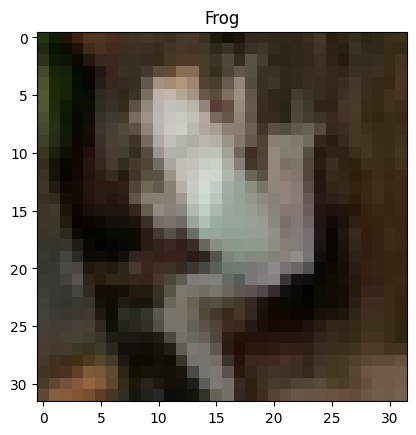

In [132]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]
training_iter = iter(train_data_loader)

data_obj, label = next(training_iter)
data_obj = data_obj[0]
data_obj = data_obj * 0.5 + 0.5
label = label[0]
data_obj = data_obj.permute(1, 2, 0)
print(data_obj, label)
plt.imshow(data_obj)
plt.title(f"{classes[label]}")

In [133]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        #Input is 32 x 32 pixels, 3 channels
        self.conv1Net = nn.Conv2d(3, 3, 5)
        # Output is 3, 28 x 28 matrices
        self.maxPool2D1 = nn.MaxPool2d(2,2)
        # Output is 3, 14 x 14 matrices
        self.conv2Net = nn.Conv2d(3, 18, 3)
        # Output is 18, 12 x 12 matrices
        self.maxPool2D2 = nn.MaxPool2d(2,2)
        # Output is 18, 6 x 6 matrices
        self.lin = nn.Linear(18 * 6 * 6, 10)

    def forward(self, x):
        x = self.maxPool2D1(F.relu(self.conv1Net(x)))
        x = self.maxPool2D2(F.relu(self.conv2Net(x)))
        x = self.lin(torch.flatten(x, 1))
        return x



In [134]:
CNN = ConvNeuralNetwork()

criteriorn = nn.CrossEntropyLoss()
optimizer = optim.SGD(CNN.parameters(), lr = 0.001)

In [135]:
max_epoch = 2
# max_epoch = 10

for epoch in range(max_epoch):
    run_loss = 0
    for data in train_data_loader:
        inputs, labels = data

        optimizer.zero_grad()

        output = CNN(inputs)
        loss = criteriorn(output, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.96862745].


tensor([8])
tensor([[[0.1451, 0.2118, 0.0706],
         [0.0706, 0.1176, 0.0314],
         [0.1294, 0.0824, 0.0275],
         ...,
         [0.1922, 0.1686, 0.0980],
         [0.2275, 0.1922, 0.1137],
         [0.2392, 0.1922, 0.1020]],

        [[0.1373, 0.1686, 0.0588],
         [0.0353, 0.0745, 0.0039],
         [0.0588, 0.0510, 0.0078],
         ...,
         [0.1961, 0.1608, 0.0941],
         [0.2196, 0.1765, 0.0980],
         [0.2235, 0.1725, 0.0863]],

        [[0.1843, 0.1922, 0.0941],
         [0.0627, 0.0980, 0.0196],
         [0.0588, 0.0863, 0.0275],
         ...,
         [0.2275, 0.1843, 0.1216],
         [0.2275, 0.1686, 0.0941],
         [0.2667, 0.2039, 0.1255]],

        ...,

        [[0.2549, 0.2157, 0.1451],
         [0.2667, 0.1922, 0.1216],
         [0.2980, 0.1961, 0.1216],
         ...,
         [0.4392, 0.3490, 0.2863],
         [0.4471, 0.3569, 0.2941],
         [0.4510, 0.3569, 0.2941]],

        [[0.2863, 0.2353, 0.1490],
         [0.3882, 0.2824, 0.1922],


Text(0.5, 1.0, 'Actual: Truck Predicted: Ship')

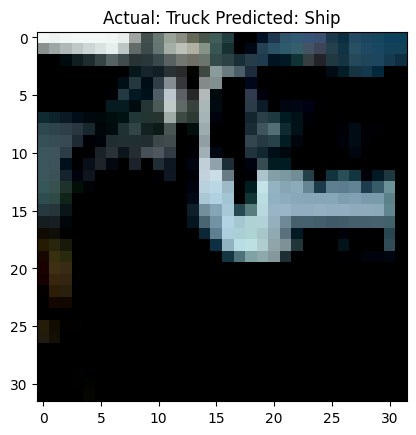

In [141]:
validation_iter = iter(validation_data_loader)

data_obj_te, label_te = next(validation_iter)
data_obj_te = data_obj_te[0]

data_obj_unorm = data_obj_te * 0.5 + 0.5
label_te = label_te[0]
data_obj_im = data_obj_te.permute(1, 2, 0)

output = CNN(data_obj_te.unsqueeze(0))
_, predicted = torch.max(output.data, 1)

print(predicted)
print(data_obj, label)
plt.imshow(data_obj_im)
plt.title(f"Actual: {classes[label_te]} Predicted: {classes[predicted]}")


Evaluating Accuracy of Convolutional Model

In [ ]:
# total = len(testing_data)
append_data = True
total = 15
correct = 0
current = 0
if total > 20:
    append_data = False

real_labels = []
predicted_labels = [] 
#check


testing_iters = iter(validation_data_loader)
with torch.no_grad():
    for images in testing_iters:
        if current >= total: break
        current += 1
        data_obj_te, label_te = images
        data_obj_te = data_obj_te[0]

        data_obj_unorm = data_obj_te * 0.5 + 0.5
        label_te = label_te[0]
        data_obj_im = data_obj_te.permute(1, 2, 0)

        output = CNN(data_obj_te.unsqueeze(0))
        _, predicted = torch.max(output.data, 1)
        if (classes[label_te] == classes[predicted]):
            correct += 1
        if append_data:
            real_labels.append(classes[label_te])
            predicted_labels.append(classes[predicted])
print(correct)
print(real_labels)
print(predicted_labels)
print("Error Rate is", 1 - (correct / total))

2
['Deer', 'Ship', 'Dog', 'Horse', 'Airplane', 'Horse', 'Cat', 'Bird', 'Ship', 'Truck', 'Deer', 'Dog', 'Truck', 'Horse', 'Cat']
['Cat', 'Ship', 'Horse', 'Cat', 'Airplane', 'Ship', 'Ship', 'Horse', 'Airplane', 'Ship', 'Horse', 'Horse', 'Frog', 'Ship', 'Horse']
Error Rate is 0.8666666666666667
